# Optimization Note 7: The Full IPM Loop — Tracing a ripopt Solve

**Goal:** See how every piece from Notes 1-6 fits together in the actual ripopt solver, by tracing a complete solve of HS071.

## The Complete Algorithm

Here is the full interior point method as implemented in ripopt's `src/ipm.rs`:

```
PREPROCESSING
├── Eliminate fixed variables (x_L = x_U)
├── Detect linear constraints (constant Jacobian)
├── Scale objective and constraints
└── Push starting point inside bounds (bound_push = 0.01)

INITIALIZATION
├── y = 0 (or least-squares estimate from J^T J y = -∇f)
├── z = μ / (x - x_L)  for bound multipliers
├── μ = 0.1
└── Choose solver: dense (n+m < 110) or sparse/multifrontal

MAIN LOOP (k = 0, 1, 2, ...)
│
├── 1. EVALUATE: f, ∇f, c, J, H at (x_k, y_k)
│
├── 2. CONVERGENCE CHECK
│   ├── Dual infeasibility:   ||∇f + J^T y - z||_∞ ≤ tol
│   ├── Primal infeasibility: ||c(x)||_∞ ≤ tol
│   ├── Complementarity:      max|z·s - μ| ≤ tol
│   └── Both scaled AND unscaled checks must pass
│
├── 3. ASSEMBLE KKT SYSTEM
│   ├── Build [H + Σ, J^T; J, -Σ_s^{-1}]
│   ├── Dense if small, sparse COO → CSC if large
│   └── Condensed Schur complement if m >> n
│
├── 4. FACTOR & INERTIA CORRECTION
│   ├── LDL^T factorization (dense BK or multifrontal)
│   ├── Check inertia from D: need (n+, m-, 0z)
│   └── If wrong: add δ_w·I, refactor (up to 15 tries)
│
├── 5. SOLVE for (Δx, Δy)
│   └── Forward/backward substitution + iterative refinement
│
├── 6. STEP COMPUTATION
│   ├── Compute Δz from complementarity
│   ├── Fraction-to-boundary: α ≤ -τ·s/Δs (τ = 0.99)
│   └── Separate α_primal and α_dual
│
├── 7. FILTER LINE SEARCH
│   ├── Try α, check filter: (θ, φ) acceptable?
│   ├── Switching condition: if θ small, require Armijo on φ
│   ├── Second-order correction if θ increased
│   ├── Backtrack: α ← α/2 (up to 40 times)
│   └── If all rejected → RESTORATION
│
├── 8. UPDATE
│   ├── x_{k+1} = x_k + α_p · Δx
│   ├── y_{k+1} = y_k + α_d · Δy  
│   └── z_{k+1}: update bound multipliers
│
└── 9. BARRIER UPDATE
    ├── Free mode: μ = avg_compl / κ
    ├── Fixed mode: μ = min(0.2·μ, μ^1.5)
    └── Switch modes based on progress
```

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=6, suppress=True)

## Tracing HS071

Let's build a complete (simplified) IPM and trace every step on the classic test problem:

$$\min \; x_1 x_4 (x_1 + x_2 + x_3) + x_3$$
$$\text{s.t.} \quad x_1 x_2 x_3 x_4 \geq 25, \quad x_1^2 + x_2^2 + x_3^2 + x_4^2 = 40, \quad 1 \leq x_i \leq 5$$

In [2]:
class HS071:
    """HS071 problem definition."""
    n = 4
    m = 2  # constraints
    x_L = np.array([1.0, 1.0, 1.0, 1.0])
    x_U = np.array([5.0, 5.0, 5.0, 5.0])
    # g1 >= 25 → g1 - 25 >= 0 → g_L[0]=25, g_U[0]=inf
    # g2 = 40  → g_L[1]=40, g_U[1]=40
    g_L = np.array([25.0, 40.0])
    g_U = np.array([1e20, 40.0])
    
    @staticmethod
    def f(x):
        return x[0]*x[3]*(x[0]+x[1]+x[2]) + x[2]
    
    @staticmethod
    def grad(x):
        return np.array([
            x[3]*(2*x[0]+x[1]+x[2]),
            x[0]*x[3],
            x[0]*x[3]+1,
            x[0]*(x[0]+x[1]+x[2])
        ])
    
    @staticmethod
    def g(x):
        return np.array([
            x[0]*x[1]*x[2]*x[3],
            x[0]**2 + x[1]**2 + x[2]**2 + x[3]**2
        ])
    
    @staticmethod
    def jac(x):
        return np.array([
            [x[1]*x[2]*x[3], x[0]*x[2]*x[3], x[0]*x[1]*x[3], x[0]*x[1]*x[2]],
            [2*x[0], 2*x[1], 2*x[2], 2*x[3]]
        ])
    
    @staticmethod
    def hess_lag(x, y):
        H = np.zeros((4, 4))
        # Objective
        H[0,0] = 2*x[3]; H[0,1] = x[3]; H[1,0] = x[3]
        H[0,2] = x[3]; H[2,0] = x[3]
        H[0,3] = 2*x[0]+x[1]+x[2]; H[3,0] = H[0,3]
        H[1,3] = x[0]; H[3,1] = x[0]; H[2,3] = x[0]; H[3,2] = x[0]
        # Constraint 1 * y[0]
        H[0,1] += y[0]*x[2]*x[3]; H[1,0] = H[0,1]
        H[0,2] += y[0]*x[1]*x[3]; H[2,0] = H[0,2]
        H[0,3] += y[0]*x[1]*x[2]; H[3,0] = H[0,3]
        H[1,2] += y[0]*x[0]*x[3]; H[2,1] = H[1,2]
        H[1,3] += y[0]*x[0]*x[2]; H[3,1] = H[1,3]
        H[2,3] += y[0]*x[0]*x[1]; H[3,2] = H[2,3]
        # Constraint 2 * y[1]
        for i in range(4): H[i,i] += 2*y[1]
        return H

In [3]:
def solve_hs071_traced(max_iter=50, tol=1e-8):
    """Solve HS071 with detailed per-iteration tracing.
    
    Introduces an explicit slack for the inequality constraint:
        g1(x) >= 25  →  g1(x) - s = 25, s >= 0
    So all constraints become equalities and we use the standard
    augmented KKT system [H+Σ, J^T; J, 0].
    """
    P = HS071
    n_orig = P.n  # 4 original variables
    n = n_orig + 1  # +1 slack for inequality g1 >= 25
    m = P.m  # 2 constraints (both equalities after slack)
    
    # === INITIALIZATION ===
    x_orig = np.array([1.0, 5.0, 5.0, 1.0])
    for i in range(n_orig):
        x_orig[i] = max(x_orig[i], P.x_L[i] + 0.01)
        x_orig[i] = min(x_orig[i], P.x_U[i] - 0.01)
    
    # Initialize slack: s = g1(x) - 25
    gval0 = P.g(x_orig)
    s_init = max(gval0[0] - P.g_L[0], 0.01)
    
    # Full variable vector: [x1, x2, x3, x4, s1]
    x = np.concatenate([x_orig, [s_init]])
    x_L = np.concatenate([P.x_L, [0.0]])
    x_U = np.concatenate([P.x_U, [np.inf]])  # slack has no upper bound
    
    # Identify finite bounds
    has_lb = np.isfinite(x_L)
    has_ub = np.isfinite(x_U)
    
    y = np.zeros(m)
    mu = 0.1
    
    # Bound multipliers (only for finite bounds)
    sl = np.where(has_lb, np.maximum(x - x_L, 1e-10), 1.0)
    su = np.where(has_ub, np.maximum(x_U - x, 1e-10), 1.0)
    zl = np.where(has_lb, mu / sl, 0.0)
    zu = np.where(has_ub, mu / su, 0.0)
    
    trace = []
    
    for k in range(max_iter):
        xv = x[:n_orig]
        s_val = x[n_orig]
        
        # === EVALUATE ===
        fval = P.f(xv)
        gf_orig = P.grad(xv)
        gval = P.g(xv)
        J_orig = P.jac(xv)
        H_orig = P.hess_lag(xv, y)
        
        # Extended to include slack variable
        gf = np.concatenate([gf_orig, [0.0]])
        
        H = np.zeros((n, n))
        H[:n_orig, :n_orig] = H_orig
        
        J = np.zeros((m, n))
        J[:, :n_orig] = J_orig
        J[0, n_orig] = -1.0  # g1(x) - s = 25
        
        # Equality constraint residuals
        c_eq = np.array([
            gval[0] - s_val - P.g_L[0],  # g1(x) - s - 25 = 0
            gval[1] - P.g_L[1]            # g2(x) - 40 = 0
        ])
        
        # Slacks to bounds (safeguarded, only for finite bounds)
        sl = np.where(has_lb, np.maximum(x - x_L, 1e-15), 1.0)
        su = np.where(has_ub, np.maximum(x_U - x, 1e-15), 1.0)
        
        # === CONVERGENCE CHECK ===
        r_dual = gf + J.T @ y - zl + zu
        theta = np.linalg.norm(c_eq, np.inf)
        dual_inf = np.linalg.norm(r_dual, np.inf)
        
        # Complementarity (only finite bounds)
        compl_vals = []
        for i in range(n):
            if has_lb[i]: compl_vals.append(abs(zl[i] * sl[i] - mu))
            if has_ub[i]: compl_vals.append(abs(zu[i] * su[i] - mu))
        compl = max(compl_vals) if compl_vals else 0.0
        
        entry = {
            'k': k, 'x': xv.copy(), 'f': fval, 'theta': theta,
            'dual_inf': dual_inf, 'compl': compl, 'mu': mu,
            'y': y.copy(), 'zl': zl.copy(), 'zu': zu.copy()
        }
        trace.append(entry)
        
        if dual_inf < tol and theta < tol and compl < tol:
            break
        
        # === BUILD KKT ===
        sigma = np.zeros(n)
        for i in range(n):
            if has_lb[i]: sigma[i] += zl[i] / sl[i]
            if has_ub[i]: sigma[i] += zu[i] / su[i]
        
        KKT = np.zeros((n+m, n+m))
        KKT[:n, :n] = H + np.diag(sigma)
        KKT[:n, n:] = J.T
        KKT[n:, :n] = J
        
        # === INERTIA CHECK ===
        delta_w = 0.0
        eigvals = np.linalg.eigvalsh(KKT)
        n_pos = np.sum(eigvals > 1e-10)
        n_neg = np.sum(eigvals < -1e-10)
        if not (n_pos == n and n_neg == m):
            delta_w = 1e-4
            for _ in range(15):
                KKT[:n, :n] = H + np.diag(sigma) + delta_w * np.eye(n)
                eigvals = np.linalg.eigvalsh(KKT)
                n_pos = np.sum(eigvals > 1e-10)
                n_neg = np.sum(eigvals < -1e-10)
                if n_pos == n and n_neg == m:
                    break
                delta_w *= 4
        
        entry['delta_w'] = delta_w
        entry['inertia'] = (n_pos, n_neg, n+m-n_pos-n_neg)
        
        # === SOLVE ===
        # RHS: z terms cancel in Newton derivation, leaving only mu/s
        rhs_d = -gf - J.T @ y
        for i in range(n):
            if has_lb[i]: rhs_d[i] += mu / sl[i]
            if has_ub[i]: rhs_d[i] -= mu / su[i]
        rhs_p = -c_eq
        
        rhs = np.concatenate([rhs_d, rhs_p])
        sol = np.linalg.solve(KKT, rhs)
        dx, dy_step = sol[:n], sol[n:]
        
        # dz from complementarity
        dzl = np.where(has_lb, (mu - zl*sl - zl*dx) / sl, 0.0)
        dzu = np.where(has_ub, (mu - zu*su + zu*dx) / su, 0.0)
        
        # === FRACTION TO BOUNDARY ===
        tau = max(0.99, 1 - mu)
        alpha_p = 1.0
        for i in range(n):
            if has_lb[i] and dx[i] < 0:
                alpha_p = min(alpha_p, -tau*sl[i]/dx[i])
            if has_ub[i] and dx[i] > 0:
                alpha_p = min(alpha_p, tau*su[i]/dx[i])
        
        alpha_d = 1.0
        for i in range(n):
            if has_lb[i] and dzl[i] < 0:
                alpha_d = min(alpha_d, -tau*zl[i]/dzl[i])
            if has_ub[i] and dzu[i] < 0:
                alpha_d = min(alpha_d, -tau*zu[i]/dzu[i])
        
        entry['alpha_p'] = alpha_p
        entry['alpha_d'] = alpha_d
        
        # === UPDATE ===
        x += alpha_p * dx
        y += alpha_d * dy_step
        zl += alpha_d * dzl
        zu += alpha_d * dzu
        zl = np.where(has_lb, np.maximum(zl, 1e-14), 0.0)
        zu = np.where(has_ub, np.maximum(zu, 1e-14), 0.0)
        
        # === BARRIER UPDATE ===
        sl_new = np.where(has_lb, np.maximum(x - x_L, 1e-15), 1.0)
        su_new = np.where(has_ub, np.maximum(x_U - x, 1e-15), 1.0)
        n_compl = np.sum(has_lb) + np.sum(has_ub)
        avg_compl = (np.dot(zl, sl_new) + np.dot(zu, su_new)) / max(n_compl, 1)
        mu = min(0.2 * mu, avg_compl / 10.0)
        mu = max(mu, 1e-12)
    
    return x[:n_orig], y, trace


x_opt, y_opt, trace = solve_hs071_traced()

In [4]:
# Print iteration summary
print(f"{'k':>3} {'f(x)':>10} {'θ':>10} {'||dual||':>10} {'compl':>10} {'μ':>10} {'α_p':>6} {'α_d':>6} {'δ_w':>8}")
print("-" * 82)
for t in trace:
    alpha_p = t.get('alpha_p', '-')
    alpha_d = t.get('alpha_d', '-')
    delta_w = t.get('delta_w', 0)
    ap_str = f"{alpha_p:.3f}" if isinstance(alpha_p, float) else alpha_p
    ad_str = f"{alpha_d:.3f}" if isinstance(alpha_d, float) else alpha_d
    print(f"{t['k']:>3} {t['f']:>10.4f} {t['theta']:>10.2e} {t['dual_inf']:>10.2e} "
          f"{t['compl']:>10.2e} {t['mu']:>10.2e} {ap_str:>6} {ad_str:>6} {delta_w:>8.1e}")

print(f"\nSolution: x = {x_opt}")
print(f"f(x*)    = {HS071.f(x_opt):.6f}")
print(f"g(x*)    = {HS071.g(x_opt)}")
print(f"Expected:  f ≈ 17.014, g1 = 25, g2 = 40")

  k       f(x)          θ   ||dual||      compl          μ    α_p    α_d      δ_w
----------------------------------------------------------------------------------
  0    16.2009   1.18e+01   1.20e+01   0.00e+00   1.00e-01  0.060  0.017  0.0e+00
  1    16.0766   1.11e+01   1.17e+01   9.34e-02   6.66e-03  0.074  0.064  0.0e+00
  2    16.1356   1.03e+01   1.09e+01   9.27e-02   1.33e-03  1.000  0.124  0.0e+00
  3    16.7551   7.16e-01   8.27e+00   8.04e-02   2.66e-04  0.580  0.592  0.0e+00
  4    16.6552   6.48e-01   3.40e+00   3.47e-02   5.33e-05  1.000  0.926  0.0e+00
  5    16.9932   4.01e-02   3.29e-01   3.35e-03   1.07e-05  1.000  0.990  0.0e+00
  6    17.0077   1.02e-02   6.57e-03   1.30e-04   2.13e-06  1.000  1.000  0.0e+00
  7    17.0140   1.99e-05   7.59e-06   2.47e-06   2.21e-07  1.000  1.000  0.0e+00
  8    17.0140   1.37e-10   7.16e-11   1.99e-07   2.21e-08  1.000  1.000  0.0e+00
  9    17.0140   9.56e-13   2.55e-13   1.98e-08   2.21e-09  1.000  1.000  0.0e+00
 10    17.0140 

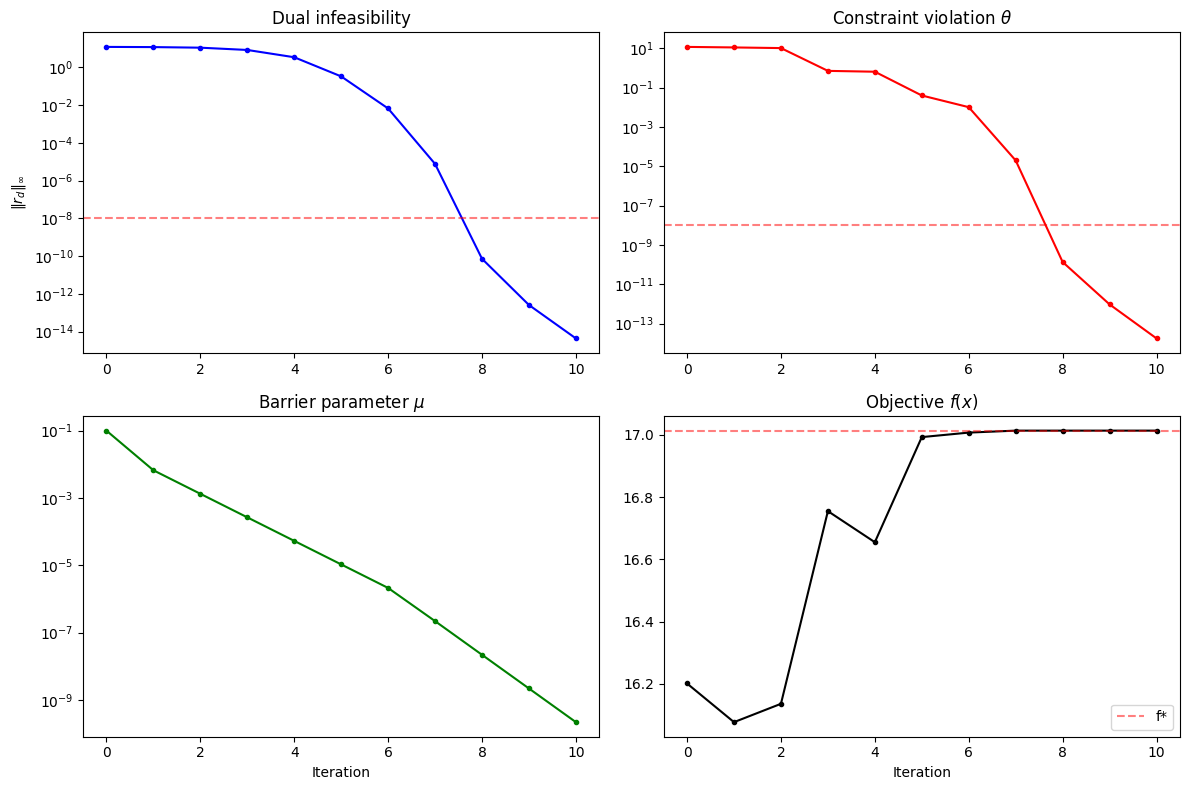

In [5]:
# Convergence plots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

iters = [t['k'] for t in trace]

axes[0,0].semilogy(iters, [max(t['dual_inf'], 1e-16) for t in trace], 'b.-')
axes[0,0].set_title('Dual infeasibility')
axes[0,0].set_ylabel('$\\|r_d\\|_\\infty$')
axes[0,0].axhline(y=1e-8, color='r', linestyle='--', alpha=0.5)

axes[0,1].semilogy(iters, [max(t['theta'], 1e-16) for t in trace], 'r.-')
axes[0,1].set_title('Constraint violation $\\theta$')
axes[0,1].axhline(y=1e-8, color='r', linestyle='--', alpha=0.5)

axes[1,0].semilogy(iters, [t['mu'] for t in trace], 'g.-')
axes[1,0].set_title('Barrier parameter $\\mu$')
axes[1,0].set_xlabel('Iteration')

axes[1,1].plot(iters, [t['f'] for t in trace], 'k.-')
axes[1,1].set_title('Objective $f(x)$')
axes[1,1].set_xlabel('Iteration')
axes[1,1].axhline(y=17.014, color='r', linestyle='--', alpha=0.5, label='f*')
axes[1,1].legend()

plt.tight_layout()
plt.show()

## Where Each Tutorial Note Appears

| Step in the solve | Tutorial note |
|---|---|
| Build KKT matrix | **Linear Note 4** (COO format), **Opt Note 4** (KKT structure) |
| Factor KKT | **Linear Note 3** (LDL^T + BK), **Linear Note 6** (multifrontal) |
| Check inertia | **Linear Note 3** (inertia from D), **Opt Note 6** (correction) |
| Solve for Δx, Δy | **Linear Note 1-2** (forward/back substitution) |
| Barrier parameter | **Opt Note 3** (log barrier), **Opt Note 4** (central path) |
| Fraction-to-boundary | **Opt Note 3** (staying feasible) |
| Filter line search | **Opt Note 2** (Armijo), **Opt Note 5** (filter) |
| Newton direction | **Opt Note 1** (quadratic model) |
| Hessian of Lagrangian | **Opt Note 5** (constraint contribution) |
| Restoration | **Opt Note 6** (Gauss-Newton, NLP) |

## Source Code Map

| Algorithm Component | ripopt file | Lines |
|---|---|---|
| Main IPM loop | `src/ipm.rs` | ~1950-3770 |
| KKT assembly (full) | `src/kkt.rs` | 45-218 |
| KKT assembly (condensed) | `src/kkt.rs` | 617-776 |
| Inertia correction | `src/kkt.rs` | 271-379 |
| Filter line search | `src/filter.rs` | full file |
| Convergence check | `src/convergence.rs` | 46-105 |
| Dense LDL^T solver | `src/linear_solver/dense.rs` | full file |
| Multifrontal solver | `rmumps/` | full crate |
| Restoration (GN + NLP) | `src/restoration.rs` | full file |
| L-BFGS approximation | `src/ipm.rs` | 258-450 |

## What We've Learned

1. The **complete IPM loop** ties together linear algebra (factorization, inertia) with optimization (barrier, line search, convergence)
2. **Preprocessing** (scaling, bound pushing, LS multiplier init) significantly affects convergence
3. **Barrier parameter update** (free vs fixed mode) adapts to problem difficulty
4. The **convergence check** uses both scaled and unscaled criteria with a dual gate
5. Every iteration follows: evaluate → assemble → factor → solve → step → accept → update μ

## What's Next

In Note 8, we survey what advanced solvers do differently, where ripopt fits in the landscape, and where there's room for improvement.

---

*This is Optimization Note 7 in a series building from Newton's method to the interior point optimizer [ripopt](https://github.com/jkitchin/ripopt).*